In [1]:
!date

Thu Sep 17 15:33:12 PDT 2026


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

In [3]:
projdir = '/u/project/cluo/terencew/claude/project_ideas/asm_lr_hprc2'
figdir = f'{projdir}/figures/qc'
outdir = f'{projdir}/results/qc/data'
!mkdir -p {figdir}

### XCI skew as an LCL clonality metric, all female donors
Promoter CpG island (chrX:73,851,123-73,852,923), computed by scripts/qsub/M03_xist_promoter_skew.py.
The earlier version of this notebook averaged the whole ~32kb XIST gene body, which diluted the
signal (skew ~0.037); the promoter window recovers it.

In [4]:
x = pd.read_csv(f'{outdir}/xist_promoter_skew.tsv', sep='\t')
man = pd.read_csv(f'{projdir}/tsv/meta/hprc2_sample_manifest.tsv', sep='\t')[
    ['sample_id', 'superpopulation']].rename(columns={'sample_id': 'sample'})
dm = pd.read_csv(f'{outdir}/qc13/donor_pmd_expansion_metrics.tsv', sep='\t')[
    ['sample', 'chemistry', 'depth_constitutive', 'global_meth']]
d = x.merge(man, on='sample', how='left').merge(dm, on='sample', how='left')

In [5]:
d.head()

,sample,hap1_meth,hap2_meth,skew,hap1_reads,hap2_reads,n_cpg_hap1,n_cpg_hap2,sex,superpopulation,chemistry,depth_constitutive,global_meth
0,HG00097,0.714926,0.243450,0.471476,28,29,59,58,female,EUR,R1041,0.245584,0.520791
1,HG00099,0.878638,0.096852,0.781786,36,23,58,58,female,EUR,R941,0.197980,0.518563
2,HG00128,0.250529,0.705984,0.455455,25,42,58,58,female,EUR,R1041,0.236361,0.522023
3,HG00133,0.399449,0.672949,0.273500,33,16,58,58,female,EUR,R1041,0.201178,0.528512
4,HG00146,0.049138,0.863576,0.814438,22,30,58,58,female,EUR,R1041,0.228861,0.522161


In [6]:
d.shape

(96, 13)

In [7]:
print('female donors: %d | median reads per hap %.0f | median CpGs in window %.0f' % (
    len(d), d[['hap1_reads', 'hap2_reads']].mean(axis=1).median(), d[['n_cpg_hap1', 'n_cpg_hap2']].mean(axis=1).median()))
print(d['skew'].describe().round(3).to_string())
print('\nclonal-like (skew > 0.5): %d/%d (%.0f%%)' % ((d['skew'] > 0.5).sum(), len(d), 100 * (d['skew'] > 0.5).mean()))
print('near-complete skew (> 0.7): %d' % (d['skew'] > 0.7).sum())

female donors: 96 | median reads per hap 32 | median CpGs in window 58
count    96.000
mean      0.394
std       0.247
min       0.011
25%       0.170
50%       0.393
75%       0.612
max       0.853

clonal-like (skew > 0.5): 35/96 (36%)
near-complete skew (> 0.7): 14


In [8]:
d.groupby('superpopulation')['skew'].agg(['size', 'median', 'max']).round(3)

,size,median,max
superpopulation,,,
AFR,33,0.559,0.853
AMR,20,0.255,0.778
EAS,13,0.282,0.719
EUR,16,0.499,0.814
SAS,14,0.266,0.765


### does clonality track the methylome state?

In [9]:
for y in ['depth_constitutive', 'global_meth']:
    s = d.dropna(subset=[y, 'chemistry'])
    f0 = smf.ols(f'{y} ~ C(chemistry)', s).fit(); f1 = smf.ols(f'{y} ~ C(chemistry) + skew', s).fit()
    print('%s: partial R2 of XIST skew %.4f, p %.3f' % (y, (f0.ssr - f1.ssr) / f0.ssr, f1.pvalues['skew']))

depth_constitutive: partial R2 of XIST skew 0.0040, p 0.543
global_meth: partial R2 of XIST skew 0.0114, p 0.303


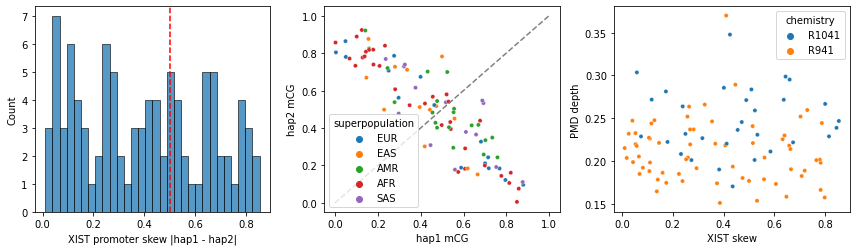

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
sns.histplot(d['skew'], bins=30, ax=axes[0]); axes[0].axvline(0.5, c='r', ls='--')
axes[0].set_xlabel('XIST promoter skew |hap1 - hap2|')
sns.scatterplot(data=d, x='hap1_meth', y='hap2_meth', hue='superpopulation', s=18, ax=axes[1])
axes[1].plot([0, 1], [0, 1], ls='--', c='grey'); axes[1].set_xlabel('hap1 mCG'); axes[1].set_ylabel('hap2 mCG')
sns.scatterplot(data=d, x='skew', y='depth_constitutive', hue='chemistry', s=18, ax=axes[2])
axes[2].set_xlabel('XIST skew'); axes[2].set_ylabel('PMD depth')
plt.tight_layout(); plt.savefig(f'{figdir}/03a_xist_promoter_skew.png', dpi=150)

In [11]:
d.to_csv(f'{outdir}/xist_promoter_skew_annotated.tsv', sep='\t', index=False)

In [12]:
!date

Thu Sep 17 15:33:17 PDT 2026
